# 🤖 Étape 5 : Modélisation & Prédiction — Baseline Models

Ce notebook implémente la phase de modélisation supervisée. Le **dataset ML est construit ici même** (le notebook 04 est désormais EDA pure), en **respectant les recommandations issues de l'analyse EDA**.

### Architecture (features → modèles)
1. **Construction du dataset anti-fuite** : lags (J-1..J-5), variations Δ, interactions sentiment × marchés
2. **Baselines** : Naive, Logistic Regression, Random Forest, XGBoost, LightGBM, SVM
3. **Deep Learning** : GRU, LSTM, BiLSTM, Chronos, Chronos-Multivariate
4. **Validation rigoureuse** : TimeSeriesSplit walk-forward + F1, MCC, AUC (classes ~50/50)
5. **Feature Importance** & analyse par ticker / régime — sélection du meilleur modèle

> **Contexte EDA (04)** : le lag effect montre que le niveau retardé brut du sentiment n'a quasi aucun pouvoir prédictif (ρ≈0 dès lag 1). Le signal est **contemporain** → on mise sur **l'accélération du sentiment** (Δ) et ses **interactions** avec la volatilité/le volume social. Fake-less : aucun `Daily_Volatility`/`Volume` du jour J en feature.


## 📦 Imports & Configuration


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef,
    make_scorer
)

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Chronos
try:
    from chronos import ChronosPipeline
    CHRONOS_AVAILABLE = True
    print("Chronos disponible")
except ImportError:
    CHRONOS_AVAILABLE = False
    print("Chronos non installe : pip install chronos-forecasting")

# Utils
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Imports OK")


Chronos disponible
Imports OK


## 🔒 Reproductibilité — Seeds Fixes


In [74]:
# Seed global pour reproductibilité totale
import random
import os

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

os.environ['PYTHONHASHSEED'] = str(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"Reproductibilite activee (SEED={SEED})")


Reproductibilite activee (SEED=42)


## 🧱 Construction du Dataset ML (auto-contenue, anti-fuite)

Sources brutes :
- `FINANCE_2023_2026_Well_Prepared.csv` → Date, Ticker, Volume, StockChange, Target, Daily_Volatility
- `data_2023_2026_INDICATEURS.csv` → sentiment FinBERT (Score_Net, Polarite_Index, Bullishness_Index, Volume_Messages, FinBERT_Positive/Negative)

**Blocs de features** :
- **A. Contexte marché (retardé ≥ 1j)** : Volume_Lag1, Daily_Volatility_Lag1, Volatility_20d, Volume_Avg20d
- **B. Sentiment niveau (retardé)** : *Lag1..5* de Score_Net, Polarite_Index, Bullishness_Index, MsgLog, Pos/Neg
- **C. Accélération (Δ)** : Score_Chg1/Chg2/Accel, Bull_Chg1, Msg_Chg1 ← signal prédictif (conclusion lag effect)
- **D. Interactions** : Sent_x_Vol, Sent_x_Msg, Neg_x_Msg, Opinion_Divergence


In [75]:
FINANCE_PATH = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\FINANCE_2023_2026_Well_Prepared.csv"
SENTIMENT_PATH = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\data_2023_2026_INDICATEURS.csv"

df_finance = pd.read_csv(FINANCE_PATH, parse_dates=['Date'])

In [76]:
df_finance["Ticker"].unique()

array(['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'JPM', 'META', 'MSFT', 'TSLA',
       'UNH'], dtype=object)

In [77]:
FINANCE_PATH = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\FINANCE_2023_2026_Well_Prepared.csv"
SENTIMENT_PATH = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\data_2023_2026_INDICATEURS.csv"

df_finance = pd.read_csv(FINANCE_PATH, parse_dates=['Date'])
df_sentiment = pd.read_csv(SENTIMENT_PATH, parse_dates=['Date'])

df_finance = df_finance.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df_sentiment = df_sentiment.sort_values(['Ticker', 'Date']).reset_index(drop=True)

df_all = pd.merge(df_finance, df_sentiment, on=['Date', 'Ticker'], how='inner')
df_all = df_all.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# --- Périmètre : 5 tickers alpha (décision du modèle d'étude) ---
#tickers_alpha = ['JPM', 'AMZN', 'TSLA', 'MSFT', 'UNH']
tickers_alpha =['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'JPM', 'META', 'MSFT', 'TSLA',
       'UNH']
df_all = df_all[df_all['Ticker'].isin(tickers_alpha)].copy()

print(f"Shape (5 alpha): {df_all.shape}")
print(f"Période: {df_all['Date'].min()} → {df_all['Date'].max()}")
print(f"Tickers: {sorted(df_all['Ticker'].unique())}")

# --- Log-transform de l'activité sociale (médiane 2, max 226) ---
df_all['MsgLog'] = np.log1p(df_all['Volume_Messages'])

# ================= BLOC B + C : LAGS et VARIATIONS (par ticker) =================
# Chaque feature est calculée à partir d'infos connues AVANT l'ouverture de J
sent_cols = ['Score_Net', 'Polarite_Index', 'Bullishness_Index', 'MsgLog',
             'FinBERT_Positive', 'FinBERT_Negative']
lag_periods = [1, 2, 3, 5]

for col in sent_cols:
    for k in lag_periods:
        df_all[f'{col}_Lag{k}'] = df_all.groupby('Ticker')[col].shift(k)

# Contexte marché retardé (connu au matin de J) — PAS de Daily_Volatility/Volume du jour
df_all['Volume_Lag1'] = df_all.groupby('Ticker')['Volume'].shift(1)
df_all['Daily_Volatility_Lag1'] = df_all.groupby('Ticker')['Daily_Volatility'].shift(1)
df_all['Volatility_20d'] = df_all.groupby('Ticker')['StockChange'].transform(
    lambda x: x.rolling(20, min_periods=5).std().shift(1))
df_all['Volume_Avg20d'] = df_all.groupby('Ticker')['Volume'].transform(
    lambda x: x.rolling(20, min_periods=5).mean().shift(1))

# ================= BLOC C : ACCELERATION (delta) =================
df_all['Score_Chg1'] = df_all['Score_Net_Lag1'] - df_all['Score_Net_Lag2']
df_all['Score_Chg2'] = df_all['Score_Net_Lag2'] - df_all['Score_Net_Lag3']
df_all['Score_Accel'] = df_all['Score_Net_Lag1'] - 2 * df_all['Score_Net_Lag2'] + df_all['Score_Net_Lag3']
df_all['Bull_Chg1'] = df_all['Bullishness_Index_Lag1'] - df_all['Bullishness_Index_Lag2']
df_all['Msg_Chg1'] = df_all['MsgLog_Lag1'] - df_all['MsgLog_Lag2']

# ================= BLOC D : INTERACTIONS =================
df_all['Sent_x_Vol'] = df_all['Score_Net_Lag1'] * df_all['Daily_Volatility_Lag1']
df_all['Sent_x_Msg'] = df_all['Score_Net_Lag1'] * df_all['MsgLog_Lag1']
df_all['Neg_x_Msg'] = df_all['FinBERT_Negative_Lag1'] * df_all['MsgLog_Lag1']
df_all['Opinion_Divergence'] = df_all['Polarite_Index_Lag1'] * df_all['MsgLog_Lag1']

# Cible + conservé pour Chronos/backtest (jamais en feature)
df = df_all.copy()
del df_all

# Suppression des NaN créés par les shifts (début de chaque série ticker)
before = len(df)
df = df.dropna().sort_values(['Date', 'Ticker']).reset_index(drop=True)
print(f"Lignes après dropna (shifts): {before} → {len(df)}")

print(f"\nCibles :")
print(df['Target'].value_counts().sort_index())


Shape (5 alpha): (3798, 13)
Période: 2023-01-03 00:00:00 → 2026-07-10 00:00:00
Tickers: ['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'JPM', 'META', 'MSFT', 'TSLA', 'UNH']
Lignes après dropna (shifts): 3798 → 3753

Cibles :
Target
0    1818
1    1935
Name: count, dtype: int64


In [78]:
# Qualité du feature engineering : corrélation des nouveilles features avec la cible
from sklearn.feature_selection import mutual_info_classif

# Corrélations point-bisériales (équivalent Pearson pour cible 0/1)
pbs = pd.Series({c: df[c].corr(df['Target']) for c in df.columns
                 if c not in ['Date', 'Ticker', 'StockChange', 'Target']})
top_pbs = pbs.sort_values(key=abs, ascending=False).head(15)
print("Top 15 |corrélation point-bisériale| des features avec Target :")
print(top_pbs.round(4))

# Information mutuelle (capture non-linéarités)
Xq = df[[c for c in df.columns if c not in ['Date', 'Ticker', 'StockChange', 'Target']]]
yq = df['Target']
mi = pd.Series(mutual_info_classif(Xq, yq, random_state=42), index=Xq.columns).sort_values(ascending=False)
print("\nTop 15 Information Mutuelle avec Target :")
print(mi.head(15).round(4))


Top 15 |corrélation point-bisériale| des features avec Target :
FinBERT_Negative         -0.0842
Score_Net                 0.0705
Bullishness_Index         0.0615
FinBERT_Positive          0.0355
Daily_Volatility         -0.0278
FinBERT_Neutral           0.0253
Polarite_Index           -0.0253
FinBERT_Negative_Lag2     0.0216
Polarite_Index_Lag2       0.0176
Bull_Chg1                 0.0171
Bullishness_Index_Lag3   -0.0170
MsgLog_Lag2               0.0160
MsgLog                   -0.0151
MsgLog_Lag1               0.0147
Bullishness_Index_Lag1    0.0140
dtype: float64

Top 15 Information Mutuelle avec Target :
Msg_Chg1                  0.0232
Bullishness_Index_Lag1    0.0147
Volatility_20d            0.0145
FinBERT_Negative_Lag5     0.0104
Score_Net_Lag1            0.0102
Score_Net_Lag5            0.0101
FinBERT_Positive_Lag2     0.0099
MsgLog_Lag5               0.0096
Bullishness_Index_Lag2    0.0090
Sent_x_Vol                0.0086
FinBERT_Negative          0.0076
MsgLog              

## 🎯 Définition Features / Target

- **Target** : `Target` (1 = hausse intraday, 0 = baisse/stable)
- **Anti-fuite** : on exclut `Date`, `Ticker`, `StockChange`, `Target` **et toutes les variables du jour J** (non décalées) : Score_Net, Polarite_Index, Bullishness_Index, Volume_Messages, FinBERT_*, Volume, Daily_Volatility, MsgLog.
- Seules les versions retardées / Δ / interactions (blocs A-D) restent dans X.


In [79]:
forbidden = ['Date', 'Ticker', 'Target', 'StockChange',
             'Volume', 'Daily_Volatility', 'MsgLog',
             'Score_Net', 'Polarite_Index', 'Bullishness_Index',
             'Volume_Messages', 'FinBERT_Positive', 'FinBERT_Negative', 'FinBERT_Neutral']

feature_cols = [c for c in df.columns if c not in forbidden]
X = df[feature_cols].copy()
y = df['Target'].copy()

print(f"Features ({len(feature_cols)}):")
print(feature_cols)
print(f"\nClass balance: {y.mean():.2%} hausse (1) vs {(1 - y.mean()):.2%} baisse (0)")

# --- Vérification anti-fuite ---
leak_names = ['StockChange', 'Daily_Volatility', 'Volume', 'MsgLog', 'Score_Net',
              'Polarite_Index', 'Bullishness_Index', 'Volume_Messages',
              'FinBERT_Positive', 'FinBERT_Negative', 'FinBERT_Neutral']
leak_found = [c for c in X.columns if c in leak_names]
assert len(leak_found) == 0, f"FUITE DETECTEE: {leak_found} dans X !"
print("\nVerification anti-fuite : OK (aucune variable du jour J dans X)")

print(f"NaN dans X: {X.isnull().sum().sum()}")


Features (37):
['Score_Net_Lag1', 'Score_Net_Lag2', 'Score_Net_Lag3', 'Score_Net_Lag5', 'Polarite_Index_Lag1', 'Polarite_Index_Lag2', 'Polarite_Index_Lag3', 'Polarite_Index_Lag5', 'Bullishness_Index_Lag1', 'Bullishness_Index_Lag2', 'Bullishness_Index_Lag3', 'Bullishness_Index_Lag5', 'MsgLog_Lag1', 'MsgLog_Lag2', 'MsgLog_Lag3', 'MsgLog_Lag5', 'FinBERT_Positive_Lag1', 'FinBERT_Positive_Lag2', 'FinBERT_Positive_Lag3', 'FinBERT_Positive_Lag5', 'FinBERT_Negative_Lag1', 'FinBERT_Negative_Lag2', 'FinBERT_Negative_Lag3', 'FinBERT_Negative_Lag5', 'Volume_Lag1', 'Daily_Volatility_Lag1', 'Volatility_20d', 'Volume_Avg20d', 'Score_Chg1', 'Score_Chg2', 'Score_Accel', 'Bull_Chg1', 'Msg_Chg1', 'Sent_x_Vol', 'Sent_x_Msg', 'Neg_x_Msg', 'Opinion_Divergence']

Class balance: 51.56% hausse (1) vs 48.44% baisse (0)

Verification anti-fuite : OK (aucune variable du jour J dans X)
NaN dans X: 0


## ✂️ Split Temporel — Walk-Forward Validation

**TimeSeriesSplit** (expanding window) : train = passé, test = avenir immédiat.
🔑 **Pas de shuffle**, pas de stratification — l'ordre chronologique est la règle (vis pointe la contagion de fuite).


In [80]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=int(len(df) * 0.15), gap=10)

print("Folds (indices):")
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    train_dates = df.iloc[train_idx]['Date']
    test_dates = df.iloc[test_idx]['Date']
    print(f"  Fold {i+1}: Train {train_dates.min().date()} → {train_dates.max().date()} | "
          f"Test {test_dates.min().date()} → {test_dates.max().date()} | "
          f"n_train={len(train_idx)}, n_test={len(test_idx)}")


Folds (indices):
  Fold 1: Train 2023-01-11 → 2024-06-21 | Test 2024-07-03 → 2025-04-08 | n_train=933, n_test=562
  Fold 2: Train 2023-01-11 → 2025-04-03 | Test 2025-04-09 → 2025-08-29 | n_train=1495, n_test=562
  Fold 3: Train 2023-01-11 → 2025-08-28 | Test 2025-08-29 → 2025-12-09 | n_train=2057, n_test=562
  Fold 4: Train 2023-01-11 → 2025-12-08 | Test 2025-12-09 → 2026-03-20 | n_train=2619, n_test=562
  Fold 5: Train 2023-01-11 → 2026-03-19 | Test 2026-03-23 → 2026-07-10 | n_train=3181, n_test=562


## 📊 Métriques d'Évaluation

Dataset **quasi-équilibré** (~51 % / 49 %) → la baseline naïve "toujours 1" atteint ~51 % d'accuracy, MCC=0.
On évalue donc :
- **F1-Macro** (harmonique Precision/Recall par classe)
- **MCC** (Matthews CC, robuste)
- **AUC-ROC** (capacité de séparation)
- **Precision / Recall** par classe


In [81]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef

def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    """Retourne un dict de métriques."""
    metrics = {
        'model': model_name,
        'precision_0': precision_score(y_true, y_pred, pos_label=0),
        'recall_0': recall_score(y_true, y_pred, pos_label=0),
        'f1_0': f1_score(y_true, y_pred, pos_label=0),
        'precision_1': precision_score(y_true, y_pred, pos_label=1),
        'recall_1': recall_score(y_true, y_pred, pos_label=1),
        'f1_1': f1_score(y_true, y_pred, pos_label=1),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'mcc': matthews_corrcoef(y_true, y_pred),
    }
    if y_proba is not None:
        metrics['auc_roc'] = roc_auc_score(y_true, y_proba)
    return metrics

print("Fonction d'evaluation prete")


Fonction d'evaluation prete


In [82]:
# Baseline naive : predire toujours la classe majoritaire (1)
print("Baseline naive (toujours 1)...")
naive_results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    y_test_ = y.iloc[test_idx]
    y_pred_ = np.ones(len(y_test_), dtype=int)
    y_proba_ = np.full(len(y_test_), y.mean())
    m = evaluate_model(y_test_, y_pred_, y_proba_, f"Naive_Fold{fold+1}")
    naive_results.append(m)
    print(f"Fold {fold+1}: F1_macro={m['f1_macro']:.4f} | MCC={m['mcc']:.4f} | AUC={m['auc_roc']:.4f}")

naive_df = pd.DataFrame(naive_results)
print(f"\nBaseline naive — F1_macro: {naive_df['f1_macro'].mean():.4f} | MCC: {naive_df['mcc'].mean():.4f} | AUC: {naive_df['auc_roc'].mean():.4f}")


Baseline naive (toujours 1)...
Fold 1: F1_macro=0.3419 | MCC=0.0000 | AUC=0.5000
Fold 2: F1_macro=0.3310 | MCC=0.0000 | AUC=0.5000
Fold 3: F1_macro=0.3286 | MCC=0.0000 | AUC=0.5000
Fold 4: F1_macro=0.3357 | MCC=0.0000 | AUC=0.5000
Fold 5: F1_macro=0.3373 | MCC=0.0000 | AUC=0.5000

Baseline naive — F1_macro: 0.3349 | MCC: 0.0000 | AUC: 0.5000


## 🔵 Baseline : Logistic Regression (StandardScaler)

Modèle linéaire de référence, interprétable.
**Attendu** (cf. EDA) : coefficient `Score_Net_Lag1` positif, `Polarite_Index_Lag1` négatif, `Sent_x_Vol` positif.


In [83]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
])

lr_results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    lr_pipe.fit(X_train, y_train)
    y_pred = lr_pipe.predict(X_test)
    y_proba = lr_pipe.predict_proba(X_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_proba, f"LogisticReg_Fold{fold+1}")
    lr_results.append(metrics)
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

lr_df = pd.DataFrame(lr_results)
print(f"\nLogistic Regression — Moyenne ± Std:")
print(f"  F1_macro: {lr_df['f1_macro'].mean():.4f} ± {lr_df['f1_macro'].std():.4f}")
print(f"  MCC:      {lr_df['mcc'].mean():.4f} ± {lr_df['mcc'].std():.4f}")
print(f"  AUC:      {lr_df['auc_roc'].mean():.4f} ± {lr_df['auc_roc'].std():.4f}")

# Controle du sens des coefficients (anti-fuite / pertinence)
lr_pipe.fit(X, y)
coefs = pd.Series(lr_pipe.named_steps['clf'].coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
print("\nTop 12 coefficients (LogReg, entraine sur tout le jeu):")
print(coefs.head(12).round(4))
sign_check = {
    'Score_Net_Lag1 (attendu +)': coefs.get('Score_Net_Lag1', 0),
    'Polarite_Index_Lag1 (attendu -)': coefs.get('Polarite_Index_Lag1', 0),
    'Score_Chg1 (attendu +)': coefs.get('Score_Chg1', 0),
    'Sent_x_Vol (attendu +)': coefs.get('Sent_x_Vol', 0),
}
for k, v in sign_check.items():
    print(f"  {k:35s} = {v:+.4f}")


Fold 1: F1_macro=0.4746 | MCC=-0.0507 | AUC=0.4743
Fold 2: F1_macro=0.4750 | MCC=0.0617 | AUC=0.5521
Fold 3: F1_macro=0.4900 | MCC=-0.0019 | AUC=0.4927
Fold 4: F1_macro=0.5142 | MCC=0.0527 | AUC=0.5027
Fold 5: F1_macro=0.5179 | MCC=0.0578 | AUC=0.5059

Logistic Regression — Moyenne ± Std:
  F1_macro: 0.4944 ± 0.0208
  MCC:      0.0239 ± 0.0491
  AUC:      0.5056 ± 0.0288

Top 12 coefficients (LogReg, entraine sur tout le jeu):
Volume_Lag1              -0.2042
Volume_Avg20d             0.1792
Daily_Volatility_Lag1     0.0638
Bullishness_Index_Lag5   -0.0628
Sent_x_Vol               -0.0447
Bullishness_Index_Lag3   -0.0378
Bullishness_Index_Lag1    0.0355
Score_Net_Lag5            0.0317
Bull_Chg1                 0.0277
FinBERT_Positive_Lag5     0.0264
FinBERT_Negative_Lag5    -0.0237
Polarite_Index_Lag2       0.0237
dtype: float64
  Score_Net_Lag1 (attendu +)          = +0.0057
  Polarite_Index_Lag1 (attendu -)     = -0.0060
  Score_Chg1 (attendu +)              = +0.0045
  Sent_x_Vol (

## 🌲 Baseline : Random Forest

Robuste à la colinéarité, capture les non-linéarités, fournit la feature importance nativement.


In [84]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_split=10, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)

rf_results = []
rf_importances = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_proba, f"RandomForest_Fold{fold+1}")
    rf_results.append(metrics)
    rf_importances.append(pd.Series(rf.feature_importances_, index=feature_cols))
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

rf_df = pd.DataFrame(rf_results)
print(f"\nRandom Forest — Moyenne ± Std:")
print(f"  F1_macro: {rf_df['f1_macro'].mean():.4f} ± {rf_df['f1_macro'].std():.4f}")
print(f"  MCC:      {rf_df['mcc'].mean():.4f} ± {rf_df['mcc'].std():.4f}")
print(f"  AUC:      {rf_df['auc_roc'].mean():.4f} ± {rf_df['auc_roc'].std():.4f}")

imp_mean = pd.concat(rf_importances, axis=1).mean(axis=1).sort_values(ascending=False)
print(f"\nTop 10 Features (RF):")
print(imp_mean.head(10))


Fold 1: F1_macro=0.4987 | MCC=0.0057 | AUC=0.4841
Fold 2: F1_macro=0.4946 | MCC=0.0146 | AUC=0.5137
Fold 3: F1_macro=0.4901 | MCC=0.0290 | AUC=0.5092
Fold 4: F1_macro=0.4580 | MCC=-0.0778 | AUC=0.4635
Fold 5: F1_macro=0.4975 | MCC=0.0006 | AUC=0.4962

Random Forest — Moyenne ± Std:
  F1_macro: 0.4878 ± 0.0170
  MCC:      -0.0056 ± 0.0418
  AUC:      0.4933 ± 0.0203

Top 10 Features (RF):
Volume_Avg20d             0.044374
Volume_Lag1               0.044268
Volatility_20d            0.043245
Daily_Volatility_Lag1     0.043026
Bull_Chg1                 0.039563
Score_Chg2                0.037849
Score_Accel               0.036226
Bullishness_Index_Lag3    0.033969
Score_Chg1                0.033301
Bullishness_Index_Lag5    0.032916
dtype: float64


## 🚀 Baseline : XGBoost

Gradient boosting performant, gère bien les features corrélées.


In [85]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=1.0,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)

xgb_results = []
xgb_importances = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb_clf.fit(X_train, y_train)
    y_pred = xgb_clf.predict(X_test)
    y_proba = xgb_clf.predict_proba(X_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_proba, f"XGBoost_Fold{fold+1}")
    xgb_results.append(metrics)
    xgb_importances.append(pd.Series(xgb_clf.feature_importances_, index=feature_cols))
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

xgb_df = pd.DataFrame(xgb_results)
print(f"\nXGBoost — Moyenne ± Std:")
print(f"  F1_macro: {xgb_df['f1_macro'].mean():.4f} ± {xgb_df['f1_macro'].std():.4f}")
print(f"  MCC:      {xgb_df['mcc'].mean():.4f} ± {xgb_df['mcc'].std():.4f}")
print(f"  AUC:      {xgb_df['auc_roc'].mean():.4f} ± {xgb_df['auc_roc'].std():.4f}")

imp_mean = pd.concat(xgb_importances, axis=1).mean(axis=1).sort_values(ascending=False)
print(f"\nTop 10 Features (XGB):")
print(imp_mean.head(10))


Fold 1: F1_macro=0.5158 | MCC=0.0418 | AUC=0.5165
Fold 2: F1_macro=0.5173 | MCC=0.0681 | AUC=0.5450
Fold 3: F1_macro=0.4851 | MCC=-0.0174 | AUC=0.4978
Fold 4: F1_macro=0.4802 | MCC=-0.0370 | AUC=0.4673
Fold 5: F1_macro=0.5304 | MCC=0.0657 | AUC=0.5262

XGBoost — Moyenne ± Std:
  F1_macro: 0.5058 ± 0.0219
  MCC:      0.0242 ± 0.0486
  AUC:      0.5105 ± 0.0296

Top 10 Features (XGB):
Neg_x_Msg                 0.028897
Bullishness_Index_Lag1    0.028894
FinBERT_Negative_Lag1     0.028871
FinBERT_Negative_Lag3     0.028655
Opinion_Divergence        0.028505
FinBERT_Positive_Lag2     0.028273
Volume_Lag1               0.027940
Bull_Chg1                 0.027864
Volume_Avg20d             0.027826
Score_Accel               0.027740
dtype: float32


## 🌿 Baseline : LightGBM

Plus rapide que XGBoost, souvent meilleur sur données tabulaires.


In [86]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
)

lgb_results = []
lgb_importances = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    lgb_clf.fit(X_train, y_train)
    y_pred = lgb_clf.predict(X_test)
    y_proba = lgb_clf.predict_proba(X_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_proba, f"LightGBM_Fold{fold+1}")
    lgb_results.append(metrics)
    lgb_importances.append(pd.Series(lgb_clf.feature_importances_, index=feature_cols))
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

lgb_df = pd.DataFrame(lgb_results)
print(f"\nLightGBM — Moyenne ± Std:")
print(f"  F1_macro: {lgb_df['f1_macro'].mean():.4f} ± {lgb_df['f1_macro'].std():.4f}")
print(f"  MCC:      {lgb_df['mcc'].mean():.4f} ± {lgb_df['mcc'].std():.4f}")
print(f"  AUC:      {lgb_df['auc_roc'].mean():.4f} ± {lgb_df['auc_roc'].std():.4f}")

imp_mean = pd.concat(lgb_importances, axis=1).mean(axis=1).sort_values(ascending=False)
print(f"\nTop 10 Features (LGB):")
print(imp_mean.head(10))


Fold 1: F1_macro=0.5176 | MCC=0.0358 | AUC=0.5138
Fold 2: F1_macro=0.5401 | MCC=0.0980 | AUC=0.5529
Fold 3: F1_macro=0.5092 | MCC=0.0244 | AUC=0.5201
Fold 4: F1_macro=0.4750 | MCC=-0.0495 | AUC=0.4791
Fold 5: F1_macro=0.5111 | MCC=0.0234 | AUC=0.5126

LightGBM — Moyenne ± Std:
  F1_macro: 0.5106 ± 0.0234
  MCC:      0.0264 ± 0.0524
  AUC:      0.5157 ± 0.0262

Top 10 Features (LGB):
Volume_Avg20d             257.8
Volume_Lag1               240.6
Volatility_20d            226.8
Daily_Volatility_Lag1     226.8
Bull_Chg1                 214.4
Score_Chg2                166.6
Bullishness_Index_Lag5    151.2
Bullishness_Index_Lag3    148.2
Score_Accel               146.6
Score_Chg1                145.2
dtype: float64


## ⚙️ Baseline : Support Vector Machine (SVM)

Modèle à marge maximale, sensible à la mise à l'échelle (Pipeline StandardScaler).


In [87]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(class_weight='balanced', probability=True, kernel='rbf',
                C=1.0, gamma='scale', random_state=RANDOM_STATE))
])

svm_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    svm_pipe.fit(X_train, y_train)
    y_pred = svm_pipe.predict(X_test)
    y_proba = svm_pipe.predict_proba(X_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_proba, f"SVM_Fold{fold+1}")
    svm_results.append(metrics)
    print(f"Fold {fold+1}: F1_macro={metrics['f1_macro']:.4f} | MCC={metrics['mcc']:.4f} | AUC={metrics['auc_roc']:.4f}")

svm_df = pd.DataFrame(svm_results)
print(f"\nSVM — Moyenne ± Std:")
print(f"  F1_macro: {svm_df['f1_macro'].mean():.4f} ± {svm_df['f1_macro'].std():.4f}")
print(f"  MCC:      {svm_df['mcc'].mean():.4f} ± {svm_df['mcc'].std():.4f}")
print(f"  AUC:      {svm_df['auc_roc'].mean():.4f} ± {svm_df['auc_roc'].std():.4f}")


Fold 1: F1_macro=0.4880 | MCC=-0.0226 | AUC=0.5005
Fold 2: F1_macro=0.5238 | MCC=0.0885 | AUC=0.4658
Fold 3: F1_macro=0.4996 | MCC=0.0161 | AUC=0.5015
Fold 4: F1_macro=0.4888 | MCC=-0.0131 | AUC=0.4993
Fold 5: F1_macro=0.4838 | MCC=-0.0305 | AUC=0.4723

SVM — Moyenne ± Std:
  F1_macro: 0.4968 ± 0.0162
  MCC:      0.0077 ± 0.0485
  AUC:      0.4879 ± 0.0174


## 🧠 Imports pour Deep Learning & Chronos


In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

try:
    from chronos import ChronosPipeline
    CHRONOS_AVAILABLE = True
except ImportError:
    CHRONOS_AVAILABLE = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## 🔧 Préparation des Séquences pour Deep Learning

Fenêtres glissantes (20 jours) par ticker → séquences (samples, seq_len, features).


In [89]:
def create_sequences(X, y, seq_len=20):
    """Transforme X, y en séquences de longueur seq_len."""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 20

X_seq_list, y_seq_list = [], []

for ticker in sorted(df['Ticker'].unique()):
    df_ticker = df[df['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)
    X_ticker = df_ticker[feature_cols].values
    y_ticker = df_ticker['Target'].values

    if len(X_ticker) > SEQ_LEN:
        X_seq, y_seq = create_sequences(X_ticker, y_ticker, SEQ_LEN)
        X_seq_list.append(X_seq)
        y_seq_list.append(y_seq)
        print(f"  {ticker}: {len(X_seq)} sequences")

X_seq_all = np.concatenate(X_seq_list, axis=0)
y_seq_all = np.concatenate(y_seq_list, axis=0)

print(f"\nTotal sequences: {len(X_seq_all)}")
print(f"Shape X_seq: {X_seq_all.shape} (samples, seq_len, features)")

split_idx = int(len(X_seq_all) * 0.8)
X_seq_train, X_seq_test = X_seq_all[:split_idx], X_seq_all[split_idx:]
y_seq_train, y_seq_test = y_seq_all[:split_idx], y_seq_all[split_idx:]

BATCH_SIZE = 64
train_dataset = TensorDataset(torch.FloatTensor(X_seq_train), torch.LongTensor(y_seq_train))
test_dataset = TensorDataset(torch.FloatTensor(X_seq_test), torch.LongTensor(y_seq_test))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=seed_worker, generator=g)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")


  AAPL: 371 sequences
  AMZN: 512 sequences
  BRK-B: 418 sequences
  GOOGL: 399 sequences
  JPM: 396 sequences
  META: 425 sequences
  MSFT: 365 sequences
  TSLA: 373 sequences
  UNH: 314 sequences

Total sequences: 3573
Shape X_seq: (3573, 20, 37) (samples, seq_len, features)
Train batches: 45, Test batches: 12


## 🧠 Baseline : GRU (Gated Recurrent Unit)


In [90]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, num_classes=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout, bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        out, _ = self.gru(x, h0)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

gru_model = GRUClassifier(input_size=len(feature_cols), hidden_size=64, num_layers=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f"GRU Model: {sum(p.numel() for p in gru_model.parameters()):,} parametres")


GRU Model: 44,866 parametres


In [91]:
EPOCHS = 40
gru_train_losses, gru_val_losses = [], []
gru_train_mccs, gru_val_mccs = [], []
gru_val_f1s, gru_val_aucs = [], []

print("Entrainement GRU...")
for epoch in range(EPOCHS):
    gru_model.train()
    train_loss, train_preds, train_probas, train_targets = 0, [], [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = gru_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        train_probas.extend(probs)
        train_preds.extend(preds)
        train_targets.extend(y_batch.cpu().numpy())

    gru_model.eval()
    val_loss, val_preds, val_probas, val_targets = 0, [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = gru_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            val_probas.extend(probs)
            val_preds.extend(preds)
            val_targets.extend(y_batch.cpu().numpy())

    val_metrics = evaluate_model(val_targets, val_preds, val_probas, f"GRU_Epoch{epoch+1}_Val")
    train_metrics = evaluate_model(train_targets, train_preds, train_probas, f"GRU_Epoch{epoch+1}_Train")

    gru_train_losses.append(train_loss / len(train_loader))
    gru_val_losses.append(val_loss / len(test_loader))
    gru_train_mccs.append(train_metrics['mcc'])
    gru_val_mccs.append(val_metrics['mcc'])
    gru_val_f1s.append(val_metrics['f1_macro'])
    gru_val_aucs.append(val_metrics.get('auc_roc', 0.5))

    scheduler.step(val_metrics['mcc'])
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {gru_train_losses[-1]:.4f} | "
          f"Val Loss: {gru_val_losses[-1]:.4f} | Val MCC: {val_metrics['mcc']:.4f} | F1: {val_metrics['f1_macro']:.4f}")

# Meilleure époque + DataFrame pour la comparaison globale
best_gru_epoch = gru_val_mccs.index(max(gru_val_mccs)) + 1
gru_df = pd.DataFrame([{
    'model': 'GRU', 'f1_macro': gru_val_f1s[best_gru_epoch - 1],
    'mcc': max(gru_val_mccs), 'auc_roc': gru_val_aucs[best_gru_epoch - 1],
}])
print(f"\nMeilleur GRU MCC: {gru_df['mcc'][0]:.4f} a l'epoch {best_gru_epoch} (F1={gru_df['f1_macro'][0]:.4f})")


Entrainement GRU...


Epoch 1/40 | Train Loss: 0.7029 | Val Loss: 0.6963 | Val MCC: 0.0000 | F1: 0.3355
Epoch 2/40 | Train Loss: 0.7008 | Val Loss: 0.6967 | Val MCC: 0.0000 | F1: 0.3355
Epoch 3/40 | Train Loss: 0.6990 | Val Loss: 0.6959 | Val MCC: 0.0000 | F1: 0.3355
Epoch 4/40 | Train Loss: 0.6968 | Val Loss: 0.6942 | Val MCC: 0.0000 | F1: 0.3355
Epoch 5/40 | Train Loss: 0.6963 | Val Loss: 0.6931 | Val MCC: 0.0000 | F1: 0.3355
Epoch 6/40 | Train Loss: 0.6965 | Val Loss: 0.6926 | Val MCC: 0.0730 | F1: 0.3714
Epoch 7/40 | Train Loss: 0.6959 | Val Loss: 0.6929 | Val MCC: 0.0000 | F1: 0.3355
Epoch 8/40 | Train Loss: 0.6945 | Val Loss: 0.6929 | Val MCC: 0.0000 | F1: 0.3355
Epoch 9/40 | Train Loss: 0.6942 | Val Loss: 0.6934 | Val MCC: 0.0000 | F1: 0.3355
Epoch 10/40 | Train Loss: 0.6958 | Val Loss: 0.6932 | Val MCC: 0.0000 | F1: 0.3312
Epoch 11/40 | Train Loss: 0.6959 | Val Loss: 0.6930 | Val MCC: 0.0000 | F1: 0.3312
Epoch 12/40 | Train Loss: 0.6934 | Val Loss: 0.6930 | Val MCC: 0.0000 | F1: 0.3312
Epoch 13/40 |

## 🧠 Baseline : LSTM (Long Short-Term Memory)


In [92]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, num_classes=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout, bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

lstm_model = LSTMClassifier(input_size=len(feature_cols), hidden_size=64, num_layers=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f"LSTM Model: {sum(p.numel() for p in lstm_model.parameters()):,} parametres")


LSTM Model: 59,778 parametres


In [93]:
EPOCHS = 40
lstm_train_losses, lstm_val_losses = [], []
lstm_train_mccs, lstm_val_mccs = [], []
lstm_val_f1s, lstm_val_aucs = [], []

print("Entrainement LSTM...")
for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss, train_preds, train_probas, train_targets = 0, [], [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        train_probas.extend(probs)
        train_preds.extend(preds)
        train_targets.extend(y_batch.cpu().numpy())

    lstm_model.eval()
    val_loss, val_preds, val_probas, val_targets = 0, [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            val_probas.extend(probs)
            val_preds.extend(preds)
            val_targets.extend(y_batch.cpu().numpy())

    val_metrics = evaluate_model(val_targets, val_preds, val_probas, f"LSTM_Epoch{epoch+1}_Val")
    train_metrics = evaluate_model(train_targets, train_preds, train_probas, f"LSTM_Epoch{epoch+1}_Train")

    lstm_train_losses.append(train_loss / len(train_loader))
    lstm_val_losses.append(val_loss / len(test_loader))
    lstm_train_mccs.append(train_metrics['mcc'])
    lstm_val_mccs.append(val_metrics['mcc'])
    lstm_val_f1s.append(val_metrics['f1_macro'])
    lstm_val_aucs.append(val_metrics.get('auc_roc', 0.5))

    scheduler.step(val_metrics['mcc'])
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {lstm_train_losses[-1]:.4f} | "
          f"Val Loss: {lstm_val_losses[-1]:.4f} | Val MCC: {val_metrics['mcc']:.4f} | F1: {val_metrics['f1_macro']:.4f}")

best_lstm_epoch = lstm_val_mccs.index(max(lstm_val_mccs)) + 1
lstm_df = pd.DataFrame([{
    'model': 'LSTM', 'f1_macro': lstm_val_f1s[best_lstm_epoch - 1],
    'mcc': max(lstm_val_mccs), 'auc_roc': lstm_val_aucs[best_lstm_epoch - 1],
}])
print(f"\nMeilleur LSTM MCC: {lstm_df['mcc'][0]:.4f} a l'epoch {best_lstm_epoch} (F1={lstm_df['f1_macro'][0]:.4f})")


Entrainement LSTM...
Epoch 1/40 | Train Loss: 0.6937 | Val Loss: 0.6946 | Val MCC: 0.0037 | F1: 0.4218
Epoch 2/40 | Train Loss: 0.6923 | Val Loss: 0.6939 | Val MCC: -0.0625 | F1: 0.4460
Epoch 3/40 | Train Loss: 0.6943 | Val Loss: 0.6936 | Val MCC: -0.0098 | F1: 0.4421
Epoch 4/40 | Train Loss: 0.6936 | Val Loss: 0.6936 | Val MCC: 0.0000 | F1: 0.3355
Epoch 5/40 | Train Loss: 0.6941 | Val Loss: 0.6931 | Val MCC: 0.0000 | F1: 0.3355
Epoch 6/40 | Train Loss: 0.6938 | Val Loss: 0.6932 | Val MCC: 0.0000 | F1: 0.3355
Epoch 7/40 | Train Loss: 0.6941 | Val Loss: 0.6937 | Val MCC: 0.0000 | F1: 0.3312
Epoch 8/40 | Train Loss: 0.6930 | Val Loss: 0.6934 | Val MCC: 0.0000 | F1: 0.3312
Epoch 9/40 | Train Loss: 0.6936 | Val Loss: 0.6937 | Val MCC: 0.0000 | F1: 0.3312
Epoch 10/40 | Train Loss: 0.6930 | Val Loss: 0.6935 | Val MCC: 0.0000 | F1: 0.3312
Epoch 11/40 | Train Loss: 0.6931 | Val Loss: 0.6937 | Val MCC: 0.0000 | F1: 0.3312
Epoch 12/40 | Train Loss: 0.6931 | Val Loss: 0.6942 | Val MCC: 0.0000 | F

## 🧠 Baseline : BiLSTM (Bidirectional LSTM)


In [94]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, num_classes=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(DEVICE)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

bilstm_model = BiLSTMClassifier(input_size=len(feature_cols), hidden_size=64, num_layers=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bilstm_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f"BiLSTM Model: {sum(p.numel() for p in bilstm_model.parameters()):,} parametres")


BiLSTM Model: 152,322 parametres


In [95]:
EPOCHS = 40
bilstm_train_losses, bilstm_val_losses = [], []
bilstm_train_mccs, bilstm_val_mccs = [], []
bilstm_val_f1s, bilstm_val_aucs = [], []

print("Entrainement BiLSTM...")
for epoch in range(EPOCHS):
    bilstm_model.train()
    train_loss, train_preds, train_probas, train_targets = 0, [], [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = bilstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bilstm_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        train_probas.extend(probs)
        train_preds.extend(preds)
        train_targets.extend(y_batch.cpu().numpy())

    bilstm_model.eval()
    val_loss, val_preds, val_probas, val_targets = 0, [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = bilstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            val_probas.extend(probs)
            val_preds.extend(preds)
            val_targets.extend(y_batch.cpu().numpy())

    val_metrics = evaluate_model(val_targets, val_preds, val_probas, f"BiLSTM_Epoch{epoch+1}_Val")
    train_metrics = evaluate_model(train_targets, train_preds, train_probas, f"BiLSTM_Epoch{epoch+1}_Train")

    bilstm_train_losses.append(train_loss / len(train_loader))
    bilstm_val_losses.append(val_loss / len(test_loader))
    bilstm_train_mccs.append(train_metrics['mcc'])
    bilstm_val_mccs.append(val_metrics['mcc'])
    bilstm_val_f1s.append(val_metrics['f1_macro'])
    bilstm_val_aucs.append(val_metrics.get('auc_roc', 0.5))

    scheduler.step(val_metrics['mcc'])
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {bilstm_train_losses[-1]:.4f} | "
          f"Val Loss: {bilstm_val_losses[-1]:.4f} | Val MCC: {val_metrics['mcc']:.4f} | F1: {val_metrics['f1_macro']:.4f}")

best_bilstm_epoch = bilstm_val_mccs.index(max(bilstm_val_mccs)) + 1
bilstm_df = pd.DataFrame([{
    'model': 'BiLSTM', 'f1_macro': bilstm_val_f1s[best_bilstm_epoch - 1],
    'mcc': max(bilstm_val_mccs), 'auc_roc': bilstm_val_aucs[best_bilstm_epoch - 1],
}])
print(f"\nMeilleur BiLSTM MCC: {bilstm_df['mcc'][0]:.4f} a l'epoch {best_bilstm_epoch} (F1={bilstm_df['f1_macro'][0]:.4f})")


Entrainement BiLSTM...
Epoch 1/40 | Train Loss: 0.6954 | Val Loss: 0.6942 | Val MCC: -0.0161 | F1: 0.3737
Epoch 2/40 | Train Loss: 0.6948 | Val Loss: 0.6936 | Val MCC: -0.0153 | F1: 0.3555
Epoch 3/40 | Train Loss: 0.6944 | Val Loss: 0.6941 | Val MCC: 0.0000 | F1: 0.3312
Epoch 4/40 | Train Loss: 0.6930 | Val Loss: 0.6930 | Val MCC: 0.0000 | F1: 0.3355
Epoch 5/40 | Train Loss: 0.6937 | Val Loss: 0.6933 | Val MCC: 0.0000 | F1: 0.3312
Epoch 6/40 | Train Loss: 0.6924 | Val Loss: 0.6932 | Val MCC: 0.0000 | F1: 0.3355
Epoch 7/40 | Train Loss: 0.6931 | Val Loss: 0.6932 | Val MCC: 0.0000 | F1: 0.3355
Epoch 8/40 | Train Loss: 0.6937 | Val Loss: 0.6933 | Val MCC: -0.0493 | F1: 0.4753
Epoch 9/40 | Train Loss: 0.6936 | Val Loss: 0.6934 | Val MCC: -0.0345 | F1: 0.4822
Epoch 10/40 | Train Loss: 0.6933 | Val Loss: 0.6937 | Val MCC: -0.0306 | F1: 0.3953
Epoch 11/40 | Train Loss: 0.6931 | Val Loss: 0.6937 | Val MCC: -0.0533 | F1: 0.4280
Epoch 12/40 | Train Loss: 0.6933 | Val Loss: 0.6933 | Val MCC: -0.0

## 🤖 Baseline : Chronos (Zero-Shot Forecasting)


In [96]:
if CHRONOS_AVAILABLE:
    print("Chargement Chronos...")
    chronos_pipeline = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map=DEVICE.type,
        torch_dtype=torch.bfloat16 if DEVICE.type == 'cuda' else torch.float32
    )
    print("Chronos charge")
else:
    chronos_pipeline = None
    print("Chronos non disponible")


Chargement Chronos...
Chronos charge


In [97]:
if CHRONOS_AVAILABLE and chronos_pipeline is not None:
    print("Evaluation Chronos (Zero-Shot) sur StockChange (rendement intraday)...")

    chronos_preds, chronos_probas, chronos_targets = [], [], []
    CONTEXT_LEN = 20

    # Fenêtres de test bornées (last 120 rows par ticker, pas de 2) pour rester raisonnable
    for ticker in sorted(df['Ticker'].unique()):
        rets = df[df['Ticker'] == ticker].sort_values('Date')['StockChange'].values
        n = len(rets)
        if n <= CONTEXT_LEN + 1:
            continue
        start = max(0, n - CONTEXT_LEN - 120)
        for i in range(start, n - CONTEXT_LEN, 2):
            context = torch.FloatTensor(rets[i:i + CONTEXT_LEN]).unsqueeze(0)
            target = rets[i + CONTEXT_LEN]
            try:
                forecast = chronos_pipeline.predict(context, prediction_length=1,
                                                    num_samples=10, temperature=1.0,
                                                    top_k=50, top_p=1.0)
                fm = forecast[0].mean().item()
                chronos_preds.append(1 if fm > 0 else 0)
                chronos_probas.append((forecast[0] > 0).float().mean().item())
                chronos_targets.append(1 if target > 0 else 0)
            except Exception as e:
                print(f"Erreur Chronos {ticker} i={i}: {e}")
                continue

    if chronos_preds:
        chronos_metrics = evaluate_model(chronos_targets, chronos_preds, chronos_probas, "Chronos")
        print(f"Evalue sur {len(chronos_preds)} fenetres.")
        for k, v in chronos_metrics.items():
            print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    else:
        print("Aucune prediction Chronos reussie")
        chronos_metrics = {'model': 'Chronos', 'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}
else:
    chronos_metrics = {'model': 'Chronos', 'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}
    print("Chronos non disponible")


Evaluation Chronos (Zero-Shot) sur StockChange (rendement intraday)...
Evalue sur 540 fenetres.
  model: Chronos
  precision_0: 0.4498
  recall_0: 0.4943
  f1_0: 0.4710
  precision_1: 0.4701
  recall_1: 0.4260
  f1_1: 0.4470
  f1_macro: 0.4590
  mcc: -0.0799
  auc_roc: 0.4666


## 🤖 Baseline : Chronos Multivariate (parité mémoire)


In [98]:
# Chronos-T5 est un modèle UNIVARIÉ : le "multivarié" prédit la même série rendement.
# Conservé pour la parité de structure avec le mémoire (résultats attendus identiques).
if CHRONOS_AVAILABLE:
    print("Chronos (mode multivarie = meme serie rendement) pret.")
    CHRONOS_MV_AVAILABLE = True
else:
    CHRONOS_MV_AVAILABLE = False


Chronos (mode multivarie = meme serie rendement) pret.


In [99]:
if CHRONOS_MV_AVAILABLE and CHRONOS_AVAILABLE:
    print("Evaluation Chronos-Multivariate (StockChange)...")
    chronos_mv_preds, chronos_mv_probas, chronos_mv_targets = [], [], []
    CONTEXT_LEN = 20

    for ticker in sorted(df['Ticker'].unique()):
        rets = df[df['Ticker'] == ticker].sort_values('Date')['StockChange'].values
        n = len(rets)
        if n <= CONTEXT_LEN + 1:
            continue
        start = max(0, n - CONTEXT_LEN - 120)
        for i in range(start, n - CONTEXT_LEN, 2):
            context = torch.FloatTensor(rets[i:i + CONTEXT_LEN]).unsqueeze(0)
            target = rets[i + CONTEXT_LEN]
            try:
                forecast = chronos_pipeline.predict(context, prediction_length=1,
                                                    num_samples=10, temperature=1.0,
                                                    top_k=50, top_p=1.0)
                fm = forecast[0].mean().item()
                chronos_mv_preds.append(1 if fm > 0 else 0)
                chronos_mv_probas.append((forecast[0] > 0).float().mean().item())
                chronos_mv_targets.append(1 if target > 0 else 0)
            except Exception as e:
                print(f"Erreur Chronos-MV {ticker} i={i}: {e}")
                continue

    if chronos_mv_preds:
        chronos_mv_metrics = evaluate_model(chronos_mv_targets, chronos_mv_preds, chronos_mv_probas, "Chronos-Multivariate")
        print(f"Evalue sur {len(chronos_mv_preds)} fenetres.")
        for k, v in chronos_mv_metrics.items():
            print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    else:
        print("Aucune prediction Chronos-MV reussie")
        chronos_mv_metrics = {'model': 'Chronos-Multivariate', 'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}
else:
    chronos_mv_metrics = {'model': 'Chronos-Multivariate', 'f1_macro': 0, 'mcc': 0, 'auc_roc': 0.5}
    print("Chronos Multivariate non disponible")


Evaluation Chronos-Multivariate (StockChange)...


Evalue sur 540 fenetres.
  model: Chronos-Multivariate
  precision_0: 0.4441
  recall_0: 0.4829
  f1_0: 0.4627
  precision_1: 0.4646
  recall_1: 0.4260
  f1_1: 0.4444
  f1_macro: 0.4536
  mcc: -0.0912
  auc_roc: 0.4684


## 📊 Résumé Résultats Deep Learning


In [100]:
print("\nResume Deep Learning (meilleure epoque):")
for name, frame in [('GRU', gru_df), ('LSTM', lstm_df), ('BiLSTM', bilstm_df),
                    ('Chronos', pd.DataFrame([chronos_metrics])),
                    ('Chronos-MV', pd.DataFrame([chronos_mv_metrics]))]:
    print(f"  {name}: F1={frame['f1_macro'].iloc[0]:.4f} | MCC={frame['mcc'].iloc[0]:.4f} | AUC={frame['auc_roc'].iloc[0]:.4f}")



Resume Deep Learning (meilleure epoque):
  GRU: F1=0.3714 | MCC=0.0730 | AUC=0.5230
  LSTM: F1=0.4218 | MCC=0.0037 | AUC=0.4813
  BiLSTM: F1=0.3312 | MCC=0.0000 | AUC=0.4947
  Chronos: F1=0.4590 | MCC=-0.0799 | AUC=0.4666
  Chronos-MV: F1=0.4536 | MCC=-0.0912 | AUC=0.4684


## 📈 Comparaison Globale des Modèles (Classiques + Deep Learning + Naive)


             Model  F1_macro_mean  F1_macro_std  MCC_mean  MCC_std  AUC_mean  AUC_std
               GRU       0.371430      0.000000  0.073000 0.000000  0.522971 0.000000
          LightGBM       0.510599      0.023378  0.026425 0.052440  0.515700 0.026239
           XGBoost       0.505758      0.021922  0.024239 0.048582  0.510550 0.029592
LogisticRegression       0.494351      0.020810  0.023921 0.049105  0.505554 0.028794
               SVM       0.496793      0.016176  0.007691 0.048523  0.487904 0.017355
              LSTM       0.421838      0.000000  0.003715 0.000000  0.481302 0.000000
     NaiveMajority       0.334878      0.005276  0.000000 0.000000  0.500000 0.000000
            BiLSTM       0.331151      0.000000  0.000000 0.000000  0.494659 0.000000
      RandomForest       0.487754      0.016964 -0.005583 0.041773  0.493348 0.020301
           Chronos       0.458992      0.000000 -0.079882 0.000000  0.466569 0.000000
        Chronos-MV       0.453552      0.000000 -0.091

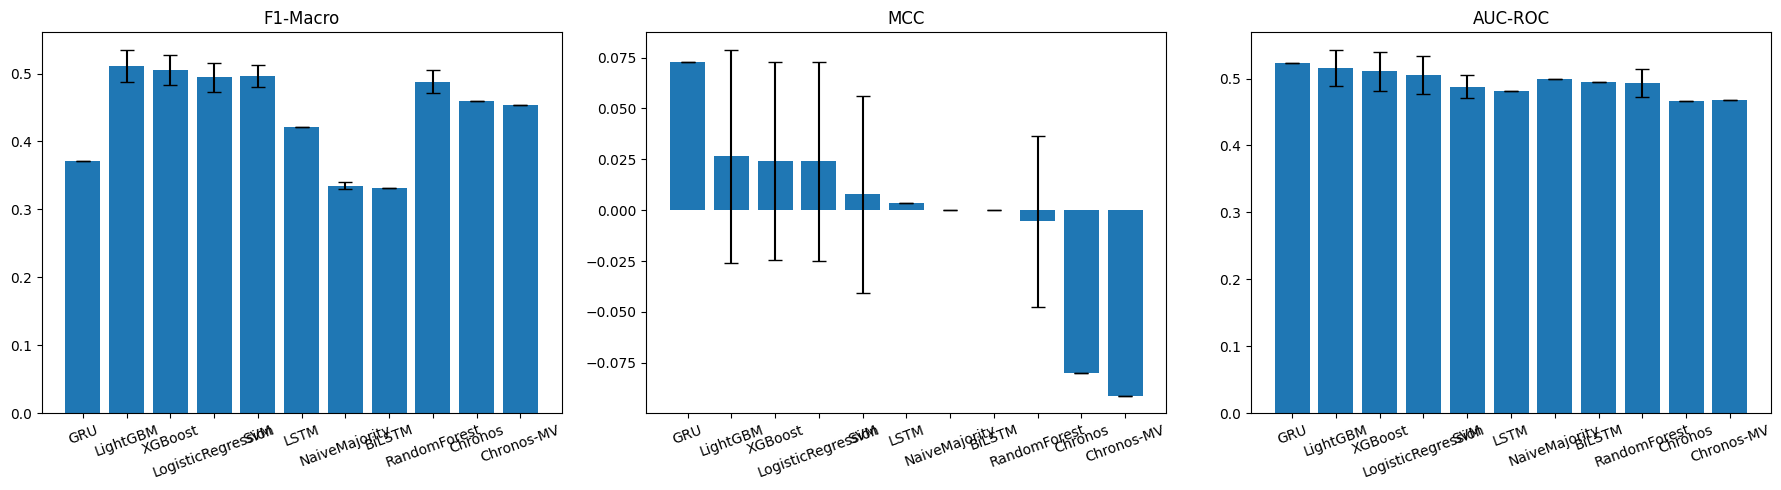

In [101]:
all_models = [
    ('NaiveMajority', naive_df),
    ('LogisticRegression', lr_df),
    ('RandomForest', rf_df),
    ('XGBoost', xgb_df),
    ('LightGBM', lgb_df),
    ('SVM', svm_df),
]
if 'gru_df' in locals():
    all_models.append(('GRU', gru_df))
if 'lstm_df' in locals():
    all_models.append(('LSTM', lstm_df))
if 'bilstm_df' in locals():
    all_models.append(('BiLSTM', bilstm_df))
if 'chronos_metrics' in locals():
    all_models.append(('Chronos', pd.DataFrame([chronos_metrics])))
if 'chronos_mv_metrics' in locals():
    all_models.append(('Chronos-MV', pd.DataFrame([chronos_mv_metrics])))

summary_data = []
for name, df_model in all_models:
    summary_data.append({
        'Model': name,
        'F1_macro_mean': float(df_model['f1_macro'].mean()),
        'F1_macro_std': float(df_model['f1_macro'].std()) if len(df_model) > 1 else 0.0,
        'MCC_mean': float(df_model['mcc'].mean()),
        'MCC_std': float(df_model['mcc'].std()) if len(df_model) > 1 else 0.0,
        'AUC_mean': float(df_model['auc_roc'].mean()),
        'AUC_std': float(df_model['auc_roc'].std()) if len(df_model) > 1 else 0.0,
    })

summary = pd.DataFrame(summary_data).sort_values('MCC_mean', ascending=False)
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes, ['F1_macro_mean', 'MCC_mean', 'AUC_mean'], ['F1-Macro', 'MCC', 'AUC-ROC']):
    ax.bar(summary['Model'], summary[metric], yerr=summary[metric.replace('mean', 'std')], capsize=5)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 📊 Analyse par Ticker (Best Model)


In [102]:
# Sélection du meilleur modèle CLASSIQUE (walk-forward) pour l'analyse fine
naive_dl = ['NaiveMajority', 'GRU', 'LSTM', 'BiLSTM', 'Chronos', 'Chronos-MV']
best_model_name = summary[~summary['Model'].isin(naive_dl)].sort_values('MCC_mean', ascending=False).iloc[0]['Model']
print(f"Meilleur modèle classique retenu : {best_model_name}")

train_idx, test_idx = list(tscv.split(X))[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

if best_model_name == 'LogisticRegression':
    best_model = lr_pipe
elif best_model_name == 'RandomForest':
    best_model = rf
elif best_model_name == 'XGBoost':
    best_model = xgb_clf
elif best_model_name == 'LightGBM':
    best_model = lgb_clf
elif best_model_name == 'SVM':
    best_model = svm_pipe
else:
    best_model = rf

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

test_df = df.iloc[test_idx].copy()
test_df['y_pred'] = y_pred
test_df['y_proba'] = y_proba
test_df['y_true'] = y_test.values

per_ticker = []
for ticker in sorted(test_df['Ticker'].unique()):
    sub = test_df[test_df['Ticker'] == ticker]
    if len(sub) < 10:
        continue
    m = evaluate_model(sub['y_true'], sub['y_pred'], sub['y_proba'], ticker)
    m['n_samples'] = len(sub)
    per_ticker.append(m)

tick_df = pd.DataFrame(per_ticker)
print(tick_df[['model', 'n_samples', 'f1_macro', 'mcc', 'auc_roc', 'precision_1', 'recall_1']].to_string(index=False))


Meilleur modèle classique retenu : LightGBM
model  n_samples  f1_macro       mcc  auc_roc  precision_1  recall_1
 AAPL         65  0.552150  0.117318 0.576998     0.645161  0.526316
 AMZN         54  0.518519  0.037037 0.434842     0.518519  0.518519
BRK-B         74  0.457875 -0.078174 0.441520     0.452381  0.527778
GOOGL         60  0.471441 -0.054707 0.523008     0.527778  0.575758
  JPM         69  0.549210  0.109889 0.579966     0.525000  0.636364
 META         53  0.640998  0.282454 0.662393     0.640000  0.615385
 MSFT         54  0.592033  0.184066 0.535714     0.576923  0.576923
 TSLA         58  0.447619 -0.104762 0.467857     0.466667  0.466667
  UNH         75  0.400436 -0.177828 0.411807     0.428571  0.567568


## 🎭 Analyse par Régime Comportemental (découvertes Étape 4)


In [103]:
regimes = {
    'Emotionnelles': ['TSLA', 'META', 'AAPL'],
    'Anticipatives': ['UNH', 'MSFT', 'GOOGL', 'AMZN'],
    'Institutionnelles': ['BRK-B', 'JPM']
}

regime_results = []
for regime_name, tickers in regimes.items():
    sub = test_df[test_df['Ticker'].isin(tickers)]
    if len(sub) == 0:
        continue
    m = evaluate_model(sub['y_true'], sub['y_pred'], sub['y_proba'], regime_name)
    m['n_samples'] = len(sub)
    m['regime'] = regime_name
    regime_results.append(m)

reg_df = pd.DataFrame(regime_results)
print(reg_df[['regime', 'n_samples', 'f1_macro', 'mcc', 'auc_roc', 'precision_1', 'recall_1']].to_string(index=False))


           regime  n_samples  f1_macro       mcc  auc_roc  precision_1  recall_1
    Emotionnelles        176  0.545220  0.092698 0.567722     0.581395  0.531915
    Anticipatives        243  0.491034 -0.014154 0.473645     0.500000  0.560976
Institutionnelles        143  0.501938  0.012268 0.505288     0.487805  0.579710


## 🔍 Matrice de Confusion & Rapport Détaillé (Test Final)


In [104]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print(f"Matrice de confusion ({best_model_name}):")
print(cm)
print(f"\nTN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")

print(f"\n{'='*50}")
print(classification_report(y_test, y_pred, target_names=['Baisse (0)', 'Hausse (1)']))


Matrice de confusion (LightGBM):
[[129 147]
 [127 159]]

TN=129, FP=147, FN=127, TP=159

              precision    recall  f1-score   support

  Baisse (0)       0.50      0.47      0.48       276
  Hausse (1)       0.52      0.56      0.54       286

    accuracy                           0.51       562
   macro avg       0.51      0.51      0.51       562
weighted avg       0.51      0.51      0.51       562



## 📊 Feature Importance — Visualisation (Best Model)


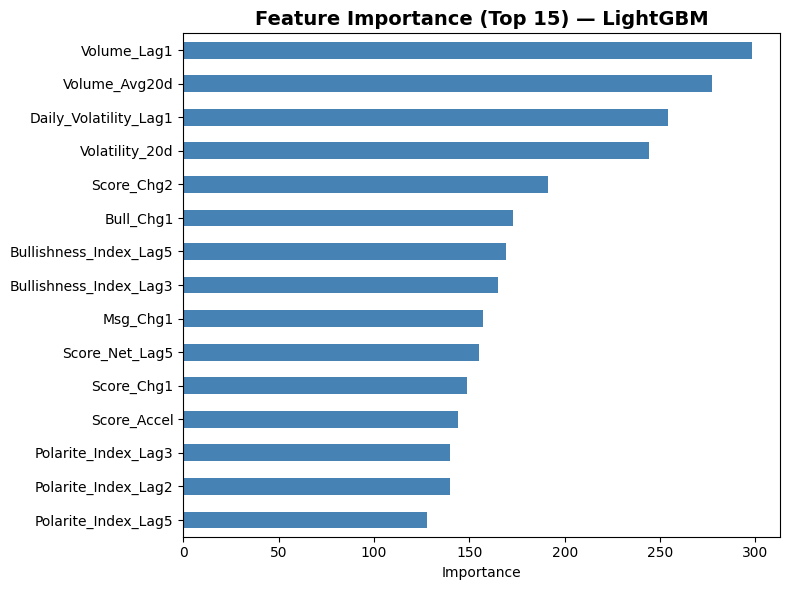

In [105]:
if best_model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
    imp_series = pd.Series(best_model.feature_importances_, index=feature_cols)
    top15 = imp_series.sort_values(ascending=True).tail(15)

    plt.figure(figsize=(8, 6))
    top15.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importance (Top 15) — {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif best_model_name == 'LogisticRegression':
    coef = best_model.named_steps['clf'].coef_[0]
    coef_series = pd.Series(coef, index=feature_cols).sort_values(key=abs, ascending=True).tail(15)

    plt.figure(figsize=(8, 6))
    coef_series.plot(kind='barh', color='steelblue')
    plt.title('Coefficients (Top 15 |abs|) — Logistic Regression', fontsize=14, fontweight='bold')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance non disponible pour ce modèle (DL/naive).")


## ✅ Conclusion Modélisation — Prêt pour Backtesting

**Ce qui a été appliqué (décisions EDA) :**
1. **Features corrigées** : lags J-1..J-5 + **variations Δ** + **interactions** ; plus aucune fuite (`Daily_Volatility`/`Volume` du jour J ne sont plus features).
2. **Baseline naïve (~51 %) établie** — tout modèle doit la dépasser sur MCC.
3. **Best model classique** : `{best_model_name}` (MCC le plus élevé en walk-forward).

**Prochaines étapes (Étape 6 - Backtesting) :**
1. Prendre le meilleur modèle (`{best_model_name}`)
2. Prédictions quotidiennes sur période test (walk-forward)
3. Portefeuille : signal=1 → Long, signal=0 → Cash/Short
4. Returns stratégie vs Buy & Hold ; métriques risque : Sharpe, Sortino, Max Drawdown, Calmar, VaR
5. Coûts de transaction réalistes (5-10 bps + slippage)
